# Setup

In [2]:

import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.sparse as sp  
from scipy.sparse import csr_matrix
from scipy.io import mmread
import json
import decoupler as dc
import colorcet as cc

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import scrublet as scr

base_dir = "/data/scottaa/cta_onco_fetal"
os.chdir(base_dir)

# Clustermap

In [ ]:
mtab_tumors_frac_df = pd.read_csv("datasets/fetal_gonad/results/tables/cta_analysis/fetal_gonad_Female_cta_fraction_expression.csv", index_col = 0)
df = pd.read_csv("datasets/embryos_mixed/results/tables/cta_analysis/embryos_mixed_female_cta_fraction_expression.csv", index_col = 0)


mtab_tumors_frac_df = pd.read_csv("datasets/mtab_tumors/results/tables/cta_analysis/mtab_tumors_cta_fraction_expression.csv", index_col = 0)
hgsoc_cta_analysis_dir = "datasets/hgsoc_tumors/results/tables/cta_analysis"
df_all_list = []
for file in os.listdir(hgsoc_cta_analysis_dir):
    if file.endswith("cta_fraction_expression.csv"):
        df_frac = pd.read_csv(os.path.join(hgsoc_cta_analysis_dir, file), index_col = 0)

        df_all_list.append(df_frac)

df = pd.concat(df_all_list, axis=1)
df = df.groupby(level=0, axis=1).mean()
df = df.fillna(0)
df

In [21]:
set(list(mtab_tumors_frac_df.index) + list(df.index))
set(list(mtab_tumors_frac_df.columns) + list(df.columns))

{'ADAM29',
 'ARX',
 'ATAD2',
 'BRDT',
 'CAGE1',
 'CCDC33',
 'CCDC36',
 'CCDC62',
 'CEP55',
 'COX6B2',
 'CRISP2',
 'CSAG1',
 'CT45A1',
 'CTCFL',
 'DSCR8',
 'ELOVL4',
 'FATE1',
 'GAGE12E',
 'GAGE2A',
 'IL13RA2',
 'MAGEB2',
 'OIP5',
 'PAGE2',
 'PAGE4',
 'PAGE5',
 'PBK',
 'PIWIL2',
 'PLAC1',
 'PRAME',
 'SLCO6A1',
 'SPA17',
 'SPAG6',
 'SSX1',
 'SYCE1',
 'TEKT5',
 'TEX15',
 'TMEFF2',
 'XAGE2',
 'XAGE3',
 'ZNF165'}

In [46]:
df_all = pd.concat([df, mtab_tumors_frac_df],axis=1)
df_all  = df_all.groupby(level=0, axis=1).mean()
df_all = df_all .fillna(0)
df_all 

/tmp/ipykernel_3955675/857732813.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_all  = df_all.groupby(level=0, axis=1).mean()


,ADAM29,ARX,ATAD2,BRDT,CAGE1,CCDC33,CCDC36,CCDC62,CEP55,COX6B2,...,SPA17,SPAG6,SSX1,SYCE1,TEKT5,TEX15,TMEFF2,XAGE2,XAGE3,ZNF165
celltype_leiden_res_1.0,,,,,,,,,,,,,,,,,,,,,
CAF,0.000000,0.000567,0.000000,0.000000,0.001323,0.004739,0.005596,0.000000,0.000000,0.020364,...,0.061611,0.000095,0.001291,0.000229,0.000457,0.000000,0.001318,0.000000,0.000000,0.004117
Cycling tumor,0.000000,0.000000,0.610075,0.000000,0.000000,0.038549,0.000000,0.001244,0.613184,0.001134,...,0.036281,0.000000,0.000000,0.000000,0.004243,0.002268,0.015181,0.003109,0.000622,0.055748
Immune,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.006780
Mixed,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000271,0.000000,0.000000,0.000000,0.000000,0.000000,0.011105
Tumor epithelial,0.001499,0.000000,0.340879,0.001082,0.001499,0.070346,0.016929,0.003551,0.169996,0.003880,...,0.050866,0.003331,0.000000,0.002304,0.004608,0.002165,0.013203,0.007989,0.000000,0.011965
Unknown,0.000000,0.000000,0.000000,0.000000,0.012346,0.000000,0.000000,0.000000,0.000000,0.005693,...,0.000000,0.000000,0.000000,0.012569,0.000569,0.000000,0.000664,0.000000,0.000000,0.011959
Activated T cells,0.000000,0.003891,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
B cells,0.012500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Endothelial,0.000000,0.000000,0.000000,0.000000,0.001603,0.011494,0.005747,0.000000,0.000000,0.002083,...,0.034483,0.000000,0.000000,0.000000,0.000000,0.000000,0.008621,0.000000,0.000000,0.000000


In [48]:
keep = [
    "Tumor epithelial",
    "Tumor epithelial (classical)",
    "Tumor epithelial (ribosomal)",
    "Tumor epithelial (mixed stromal)",
    "Tumor epithelial (stress-responsive)",
    "Epithelial (stress/EMT)",
    "Cycling tumor",
    "Hypoxic tumor",
    "Secretory tumor",
    "Transitional tumor state",
    "Tumor (IFN-response)",
    "Tumor (CTA-high)",
    "CAF"
]

df_all = df_all.loc[df_all.index.intersection(keep)]

df_all

,ADAM29,ARX,ATAD2,BRDT,CAGE1,CCDC33,CCDC36,CCDC62,CEP55,COX6B2,...,SPA17,SPAG6,SSX1,SYCE1,TEKT5,TEX15,TMEFF2,XAGE2,XAGE3,ZNF165
celltype_leiden_res_1.0,,,,,,,,,,,,,,,,,,,,,
CAF,0.000000,0.000567,0.000000,0.000000,0.001323,0.004739,0.005596,0.000000,0.000000,0.020364,...,0.061611,0.000095,0.001291,0.000229,0.000457,0.000000,0.001318,0.000000,0.000000,0.004117
Cycling tumor,0.000000,0.000000,0.610075,0.000000,0.000000,0.038549,0.000000,0.001244,0.613184,0.001134,...,0.036281,0.000000,0.000000,0.000000,0.004243,0.002268,0.015181,0.003109,0.000622,0.055748
Tumor epithelial,0.001499,0.000000,0.340879,0.001082,0.001499,0.070346,0.016929,0.003551,0.169996,0.003880,...,0.050866,0.003331,0.000000,0.002304,0.004608,0.002165,0.013203,0.007989,0.000000,0.011965
Epithelial (stress/EMT),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Hypoxic tumor,0.000000,0.000000,0.338801,0.000000,0.000000,0.000000,0.000000,0.001131,0.240385,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011878,0.000000,0.001131,0.000566
Secretory tumor,0.000000,0.000000,0.253145,0.000000,0.000000,0.000000,0.000000,0.003669,0.123166,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000524,0.005765,0.000524,0.016247
Transitional tumor state,0.000000,0.000000,0.658590,0.000000,0.000000,0.000000,0.000000,0.007709,0.623348,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011013,0.000000,0.095815
Tumor (IFN-response),0.000000,0.000000,0.305945,0.000000,0.000000,0.000000,0.000000,0.004083,0.259505,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.135749,0.003062,0.000255,0.007145
Tumor epithelial (classical),0.000000,0.000000,0.782152,0.000000,0.000000,0.000000,0.000000,0.003500,0.328959,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001750,0.001750,0.000875,0.052493


In [ ]:
all_cancer_celltypes_order = [
    "Tumor epithelial",
    "Tumor epithelial (classical)",
    "Tumor epithelial (ribosomal)",
    "Tumor epithelial (stress-responsive)",
    "Tumor epithelial (mixed stromal)",
    "Epithelial (stress/EMT)",
    "Cycling tumor",
    "Hypoxic tumor",
    "Secretory tumor",
    "Transitional tumor state",
    "Tumor (IFN-response)",
    "IFN-response",
    "CAF",
    "Perivascular",
    "Endothelial",
    "Myeloid",
    "pDC",
    "B cells",
    "Plasma cells",
    "T cells",
    "CD8 T cells",
    "Activated T cells",
    "NK cells",
    "Mast cells",
    "Erythroid",
    "Immune",
    "Mixed",
    "Unknown"
]

all_cancer_gene_order = [
    "MAGEB2","PRAME","GAGE2A","GAGE12E","PAGE2","PAGE4","PAGE5","SSX1","CAGE1","XAGE2","XAGE3","CT45A1","CSAG1",
    "PIWIL2","SYCE1","TEX15","SPA17","SPAG6","TEKT5","BRDT","CRISP2",
    "CEP55","PBK","OIP5","ATAD2",
    "IL13RA2","TMEFF2","PLAC1","ELOVL4","COX6B2",
    "ZNF165","CTCFL","ARX",
    "SLCO6A1","ADAM29","FATE1","DSCR8","CCDC33","CCDC36","CCDC62"
]

fetal_genes =  [

    # Early germ cell / pluripotency
    "PRDM14", "DPPA2", "NR6A1",

    # PGC / early germline
    "PRAME", "FAM133A",

    # Meiosis initiation / recombination
    "SPO11", "SYCP1", "HORMAD1", "HORMAD2",

    # Meiotic / germline machinery
    "TDRD1", "TDRD6", "MAEL", "TEX15", "RBM46", "MORC1",

    # Late germline / spermatogenic
    "TEX101", "TMPRSS12", "DMRT1", "BRDT",

    # Cancer-testis antigens (classic CTGs)
    "MAGEA4", "MAGEB2", "MAGEC2",
    "PAGE1", "PAGE2", "PAGE2B", "PAGE4", "PAGE5",
    "CTAG2", "CT47B1", "CTCFL",

    # Other CTGs / miscellaneous
    "CABYR", "SPANXN2", "LY6K", "TPTE", "PBK", "PLAC1",
    "IL13RA2", "LUZP4", "FMR1NB"
]

gene_order_combined = list(set(fetal_genes + all_cancer_gene_order))

In [52]:
gene_order = [g for g in gene_order_combined if g in df_all.columns]
df_all = df_all[gene_order]

gene_order

['PLAC1',
 'TEKT5',
 'CCDC62',
 'SPAG6',
 'PBK',
 'GAGE2A',
 'FATE1',
 'CCDC36',
 'PAGE5',
 'SSX1',
 'ATAD2',
 'CRISP2',
 'ELOVL4',
 'XAGE3',
 'CEP55',
 'IL13RA2',
 'CT45A1',
 'TMEFF2',
 'DSCR8',
 'CCDC33',
 'TEX15',
 'BRDT',
 'CTCFL',
 'XAGE2',
 'OIP5',
 'PAGE2',
 'GAGE12E',
 'PIWIL2',
 'CAGE1',
 'COX6B2',
 'ZNF165',
 'SYCE1',
 'ADAM29',
 'PRAME',
 'SLCO6A1',
 'MAGEB2',
 'ARX',
 'PAGE4',
 'CSAG1',
 'SPA17']

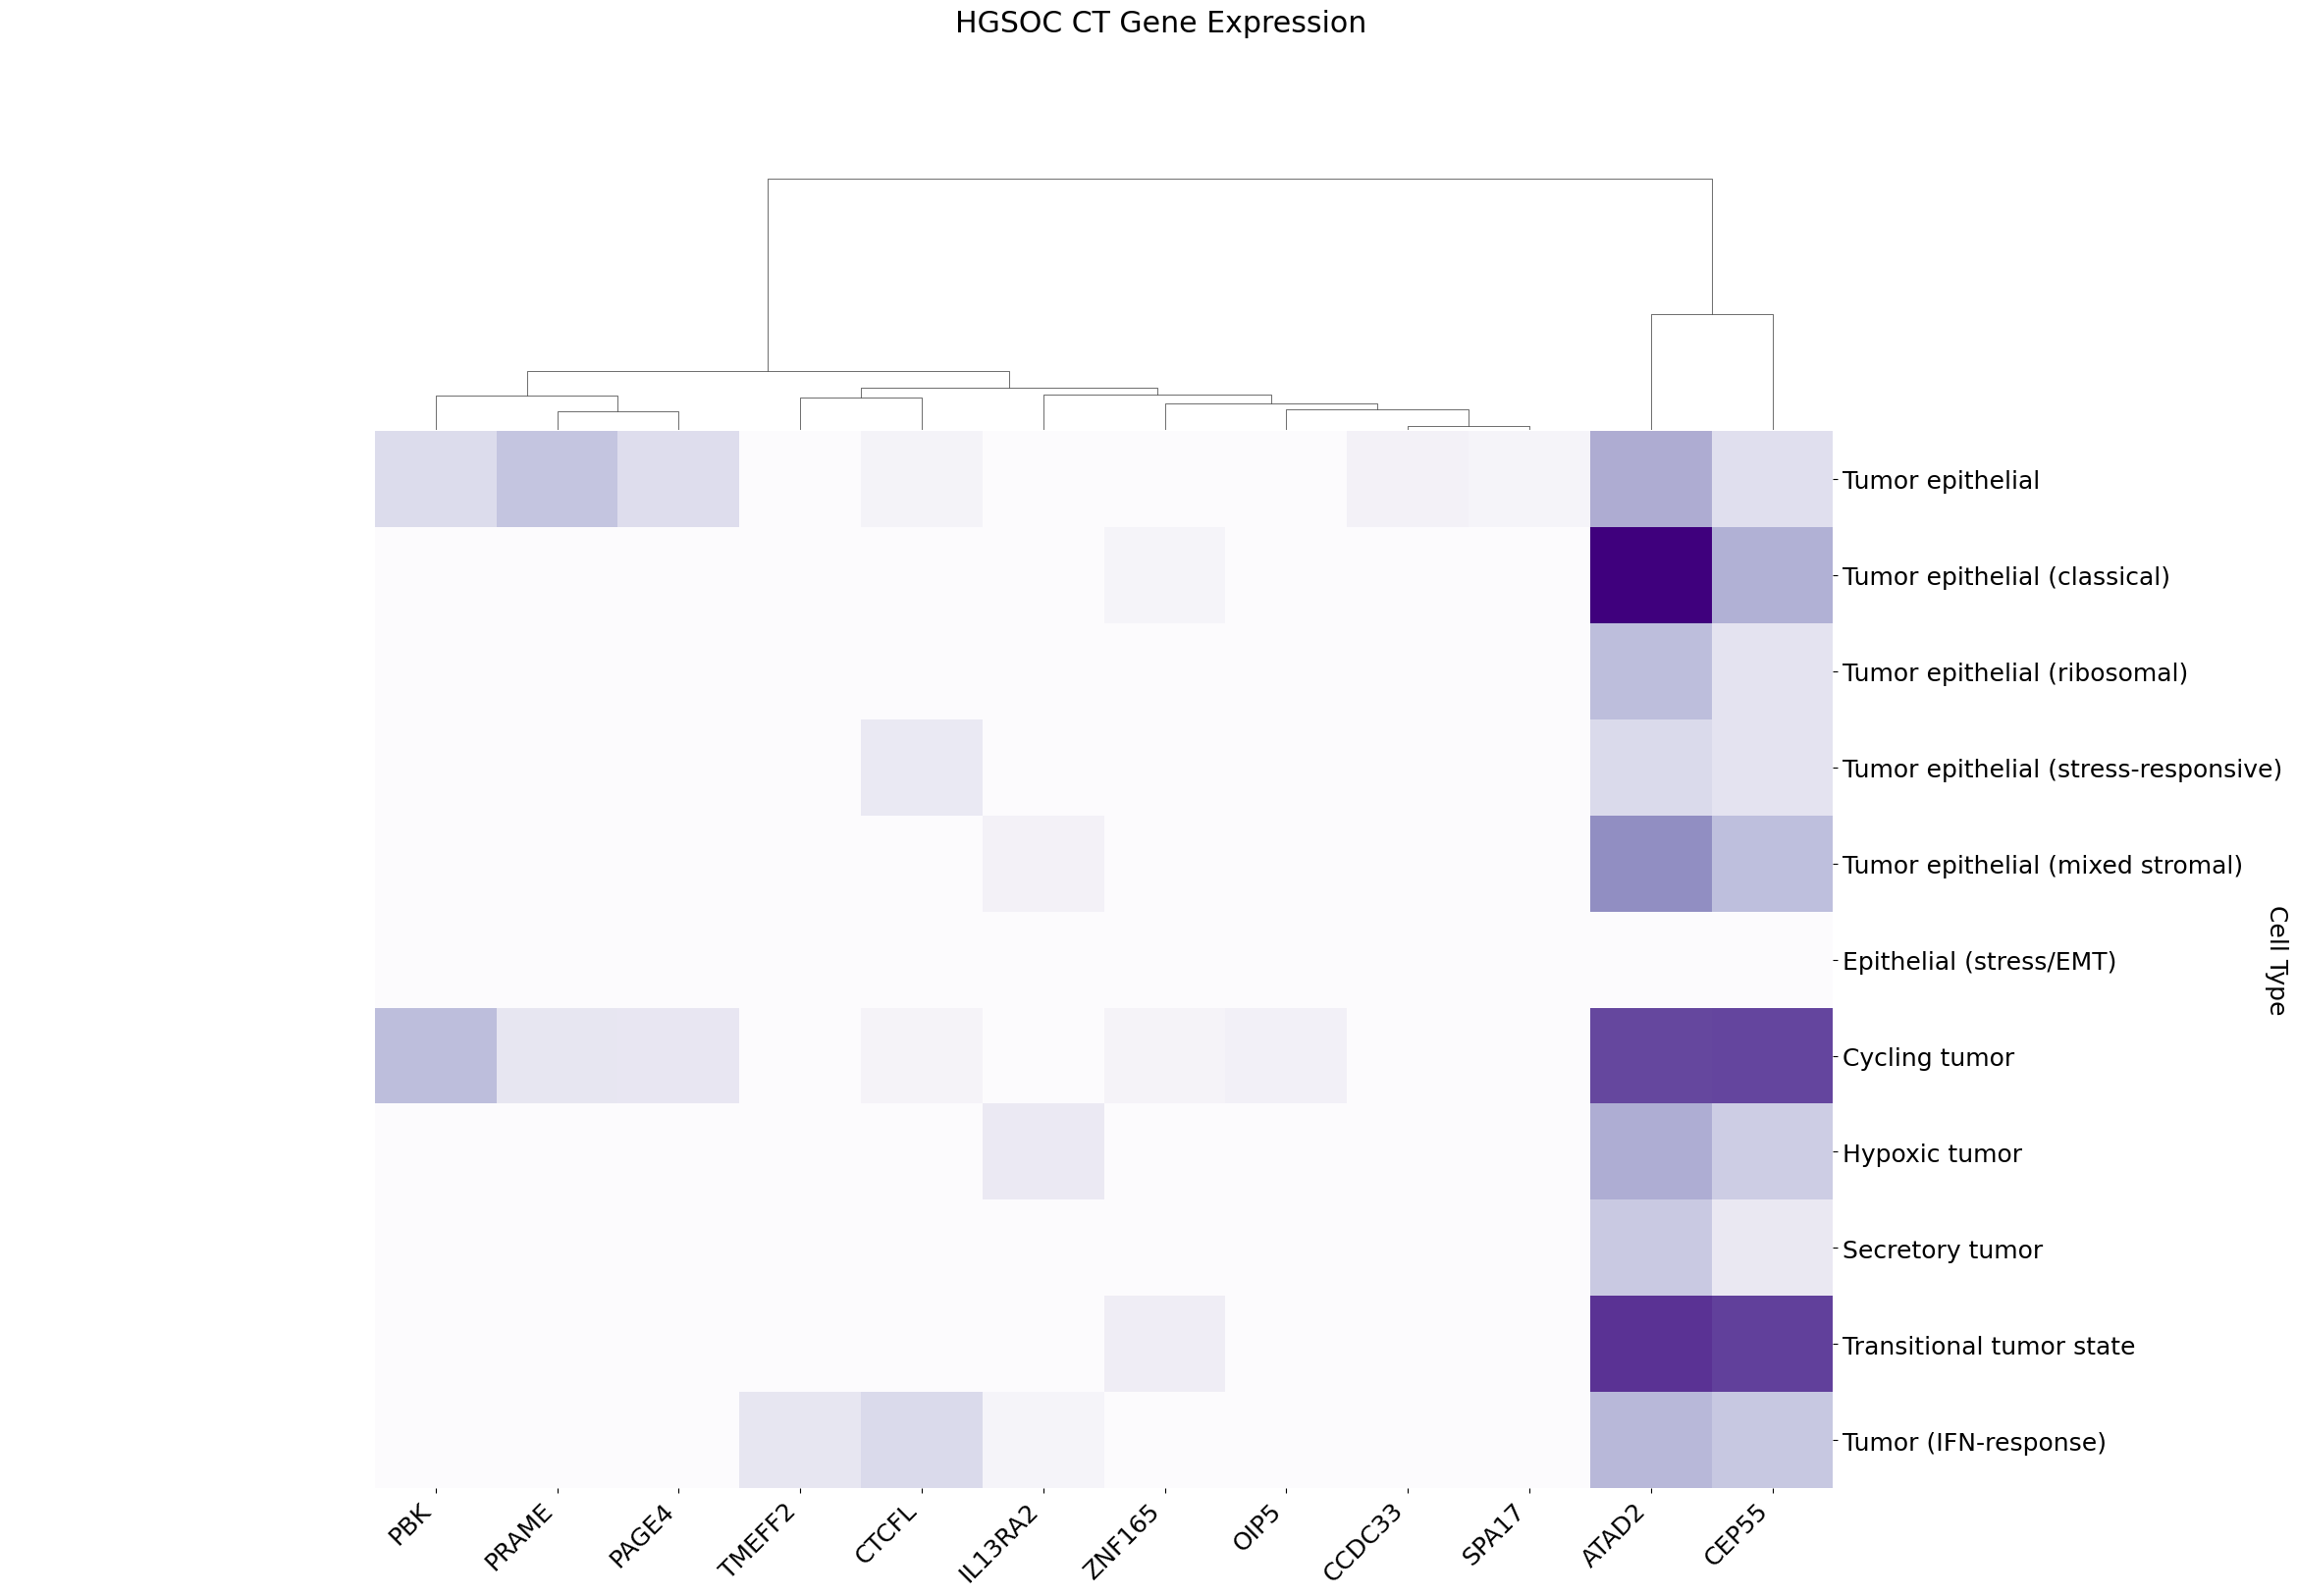

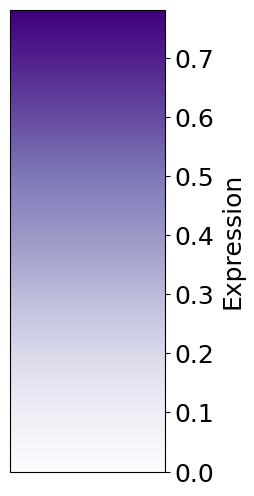

In [63]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- filter tumor / epithelial rows ---
tumor_rows = [
    "Tumor epithelial",
    "Tumor epithelial (classical)",
    "Tumor epithelial (ribosomal)",
    "Tumor epithelial (mixed stromal)",
    "Tumor epithelial (stress-responsive)",
    "Epithelial (stress/EMT)",
    "Cycling tumor",
    "Hypoxic tumor",
    "Secretory tumor",
    "Transitional tumor state",
    "Tumor (IFN-response)",
    "Tumor (CTA-high)", "CAF"
]

tumor_rows = [r for r in tumor_rows if r in df_all.index]
df_all = df_all.loc[tumor_rows]

# --- enforce cell type order ---
all_cancer_celltypes_order = [c for c in all_cancer_celltypes_order if c in df_all.index]
df_all = df_all.loc[all_cancer_celltypes_order]

# --- enforce gene order ---
gene_order = [g for g in list(set(fetal_genes + all_cancer_gene_order))if g in df_all.columns]
df_all = df_all[gene_order]

# --- plotting ---
plt.rcParams['font.size'] = 18
df_all = df_all.loc[:, (df_all > 0.001).any(axis=0)]
g = sns.clustermap(
    df_all,
    row_cluster=False,
    col_cluster=True,
    cmap="Purples",
    cbar_pos=None,
    figsize=(24, 16)
)

g.fig.suptitle("HGSOC CT Gene Expression")
g.fig.subplots_adjust(top=0.88)

g.ax_heatmap.set_ylabel("Cell Type", rotation=270)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')

# --- standalone colorbar ---
vmin = df_all.min().min()
vmax = df_all.max().max()

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.cm.Purples

fig, ax = plt.subplots(figsize=(2, 6))
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm)
cb.set_label("Expression")

plt.show()

In [72]:
set(fetal_genes) & set(all_cancer_gene_order)

{'BRDT',
 'CTCFL',
 'IL13RA2',
 'MAGEB2',
 'PAGE2',
 'PAGE4',
 'PAGE5',
 'PBK',
 'PLAC1',
 'PRAME',
 'TEX15'}

                                                 Term   P-value  \
29  negative regulation of cellular process (GO:00...  0.037129   
27  negative regulation of apoptotic process (GO:0...  0.027924   
24  negative regulation of programmed cell death (...  0.017768   
32  regulation of gene expression, epigenetic (GO:...  0.044197   
31  negative regulation of developmental process (...  0.041554   
30            regulation of RNA splicing (GO:0043484)  0.041025   
28   regulation of RNA metabolic process (GO:0051252)  0.035183   
26  regulation of stress-activated MAPK cascade (G...  0.026629   
25                   protein methylation (GO:0006479)  0.022326   
22  regulation of reactive oxygen species biosynth...  0.015296   

    Combined Score  
29       25.206311  
27       32.113030  
24       46.341250  
32       76.660323  
31       83.340087  
30       84.796006  
28      104.207383  
26      150.627939  
25      189.616212  
22      309.051915  


/tmp/ipykernel_3955675/3489105740.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


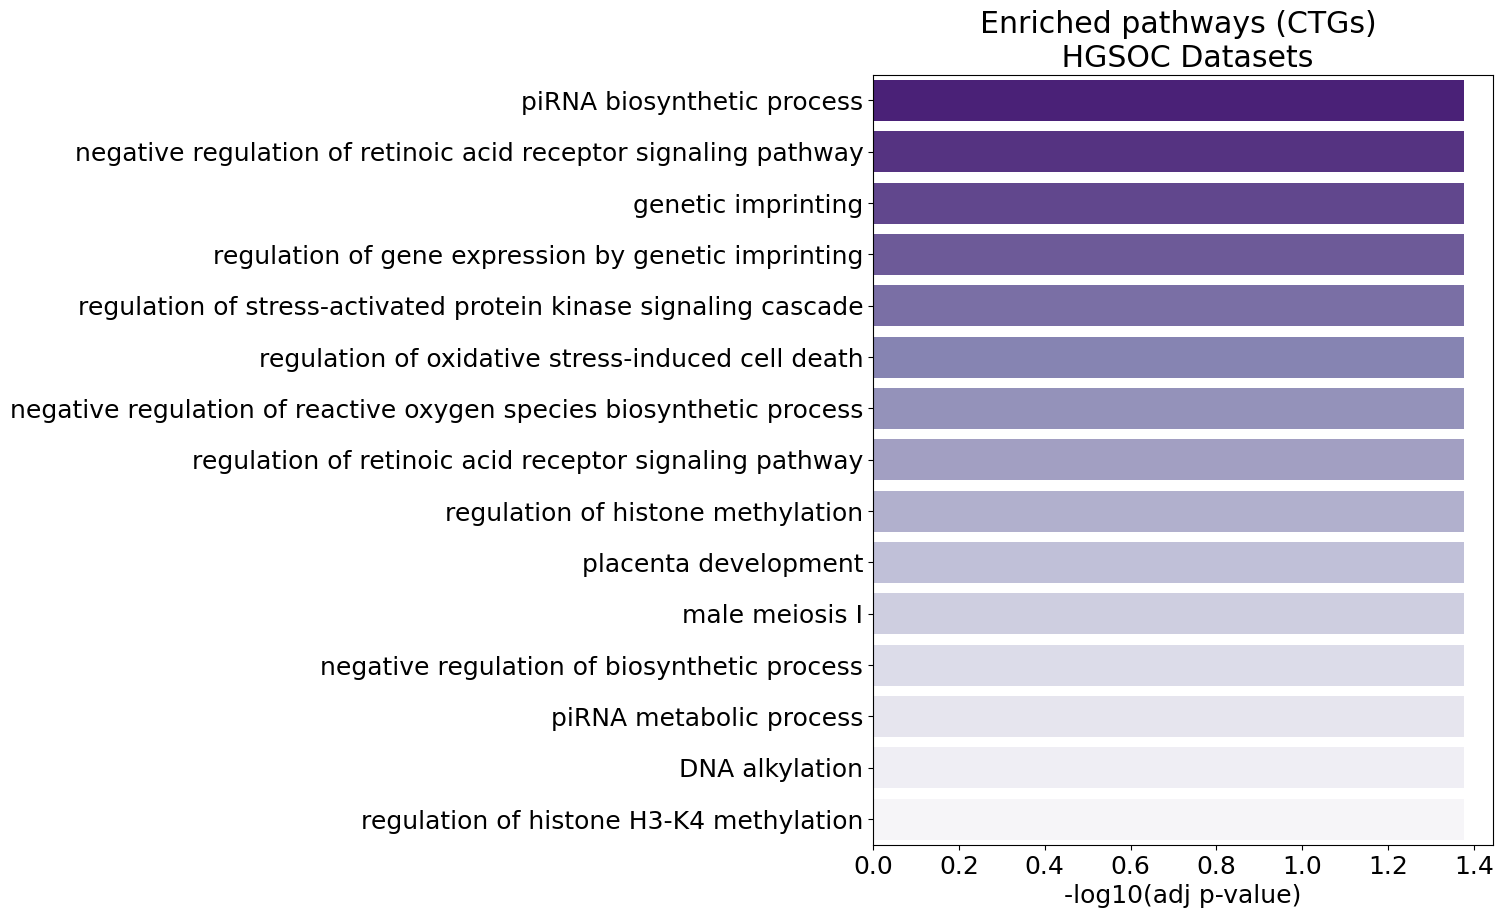

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

# run Enrichr
enr = gp.enrichr(gene_list=['BRDT',
 'CTCFL',
 'IL13RA2',
 'MAGEB2',
 'PAGE2',
 'PAGE4',
 'PAGE5',
 'PBK',
 'PLAC1',
 'PRAME',
 'TEX15'],gene_sets=["GO_Biological_Process_2021",],organism="Human", outdir=None)

# get results
results = enr.results
sig = results[results["P-value"] < 0.05]


# sort
sig = sig.sort_values("Combined Score")

# print top pathways
print(sig[["Term", "P-value", "Combined Score"]].head(10))


# take top pathways (already sorted by adjusted p-value ideally)
top = results.sort_values("Adjusted P-value").head(15)

# shorten names (optional but helps)
top["Term"] = top["Term"].str.replace(r"\s*\(GO:.*\)", "", regex=True)

plt.figure(figsize = (8,10))
palette = sns.color_palette("Purples",  n_colors=len(top))[::-1]

sns.barplot(
    data=top,
    x=-np.log10(top["Adjusted P-value"]),
    y="Term",
    palette=palette
)

plt.xlabel("-log10(adj p-value)")
plt.ylabel("")
plt.title("Enriched pathways (CTGs) \n HGSOC Datasets")
#plt.tight_layout()
plt.savefig("Combined HGSOC Datasets.png", dpi=300)
plt.show()

# Enrichr

                                                 Term   P-value  \
44  negative regulation of programmed cell death (...  0.040329   
51  negative regulation of stress fiber assembly (...  0.046938   
53               ncRNA 3'-end processing (GO:0043628)  0.046938   
52     wound healing, spreading of cells (GO:0044319)  0.046938   
50  negative regulation of reactive oxygen species...  0.045026   
49        cilium-dependent cell motility (GO:0060285)  0.045026   
48                       DNA methylation (GO:0006306)  0.045026   
47  mitochondrial calcium ion homeostasis (GO:0051...  0.043110   
46  cellular response to estradiol stimulus (GO:00...  0.041191   
45  autonomic nervous system development (GO:0048483)  0.041191   

    Combined Score  
44       13.486006  
51       67.988595  
53       67.988595  
52       67.988595  
50       72.049020  
49       72.049020  
48       72.049020  
47       76.542313  
46       81.537913  
45       81.537913  


/tmp/ipykernel_3955675/3525426077.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


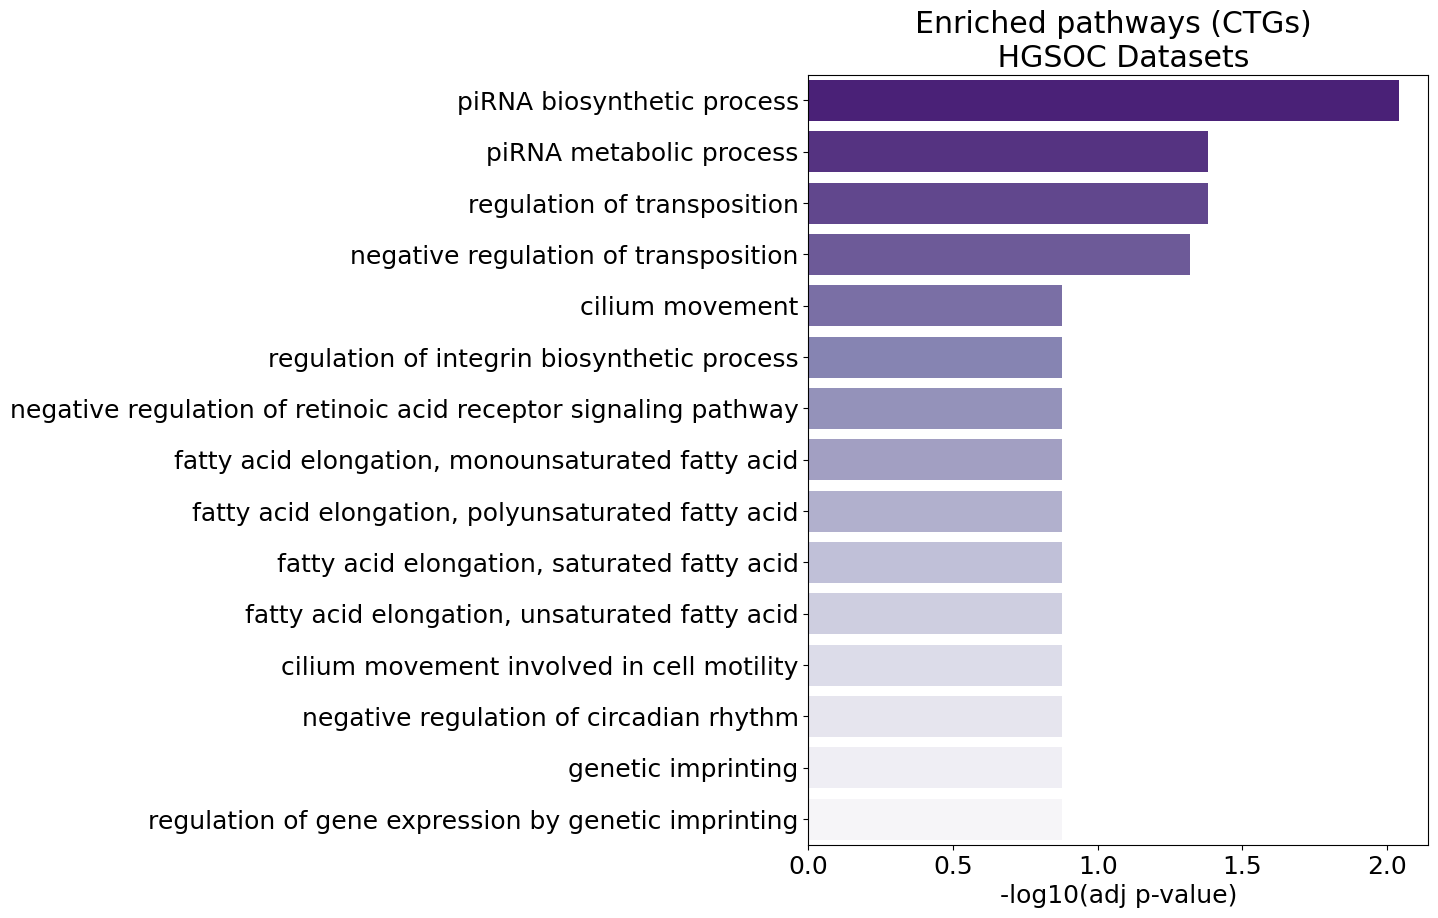

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

# run Enrichr
enr = gp.enrichr(gene_list=all_cancer_gene_order,gene_sets=["GO_Biological_Process_2021",],organism="Human", outdir=None)

# get results
results = enr.results
sig = results[results["P-value"] < 0.05]


# sort
sig = sig.sort_values("Combined Score")

# print top pathways
print(sig[["Term", "P-value", "Combined Score"]].head(10))


# take top pathways (already sorted by adjusted p-value ideally)
top = results.sort_values("Adjusted P-value").head(15)

# shorten names (optional but helps)
top["Term"] = top["Term"].str.replace(r"\s*\(GO:.*\)", "", regex=True)

plt.figure(figsize = (8,10))
palette = sns.color_palette("Purples",  n_colors=len(top))[::-1]

sns.barplot(
    data=top,
    x=-np.log10(top["Adjusted P-value"]),
    y="Term",
    palette=palette
)

plt.xlabel("-log10(adj p-value)")
plt.ylabel("")
plt.title("Enriched pathways (CTGs) \n HGSOC Datasets")
#plt.tight_layout()
plt.savefig("Combined HGSOC Datasets.png", dpi=300)
plt.show()

In [68]:
results.Genes

0      PIWIL2;TEX15
1      PIWIL2;TEX15
2      PIWIL2;TEX15
3      PIWIL2;TEX15
4       TEKT5;SPA17
           ...     
151           PRAME
152         IL13RA2
153           PRAME
154            SSX1
155           PRAME
Name: Genes, Length: 156, dtype: object

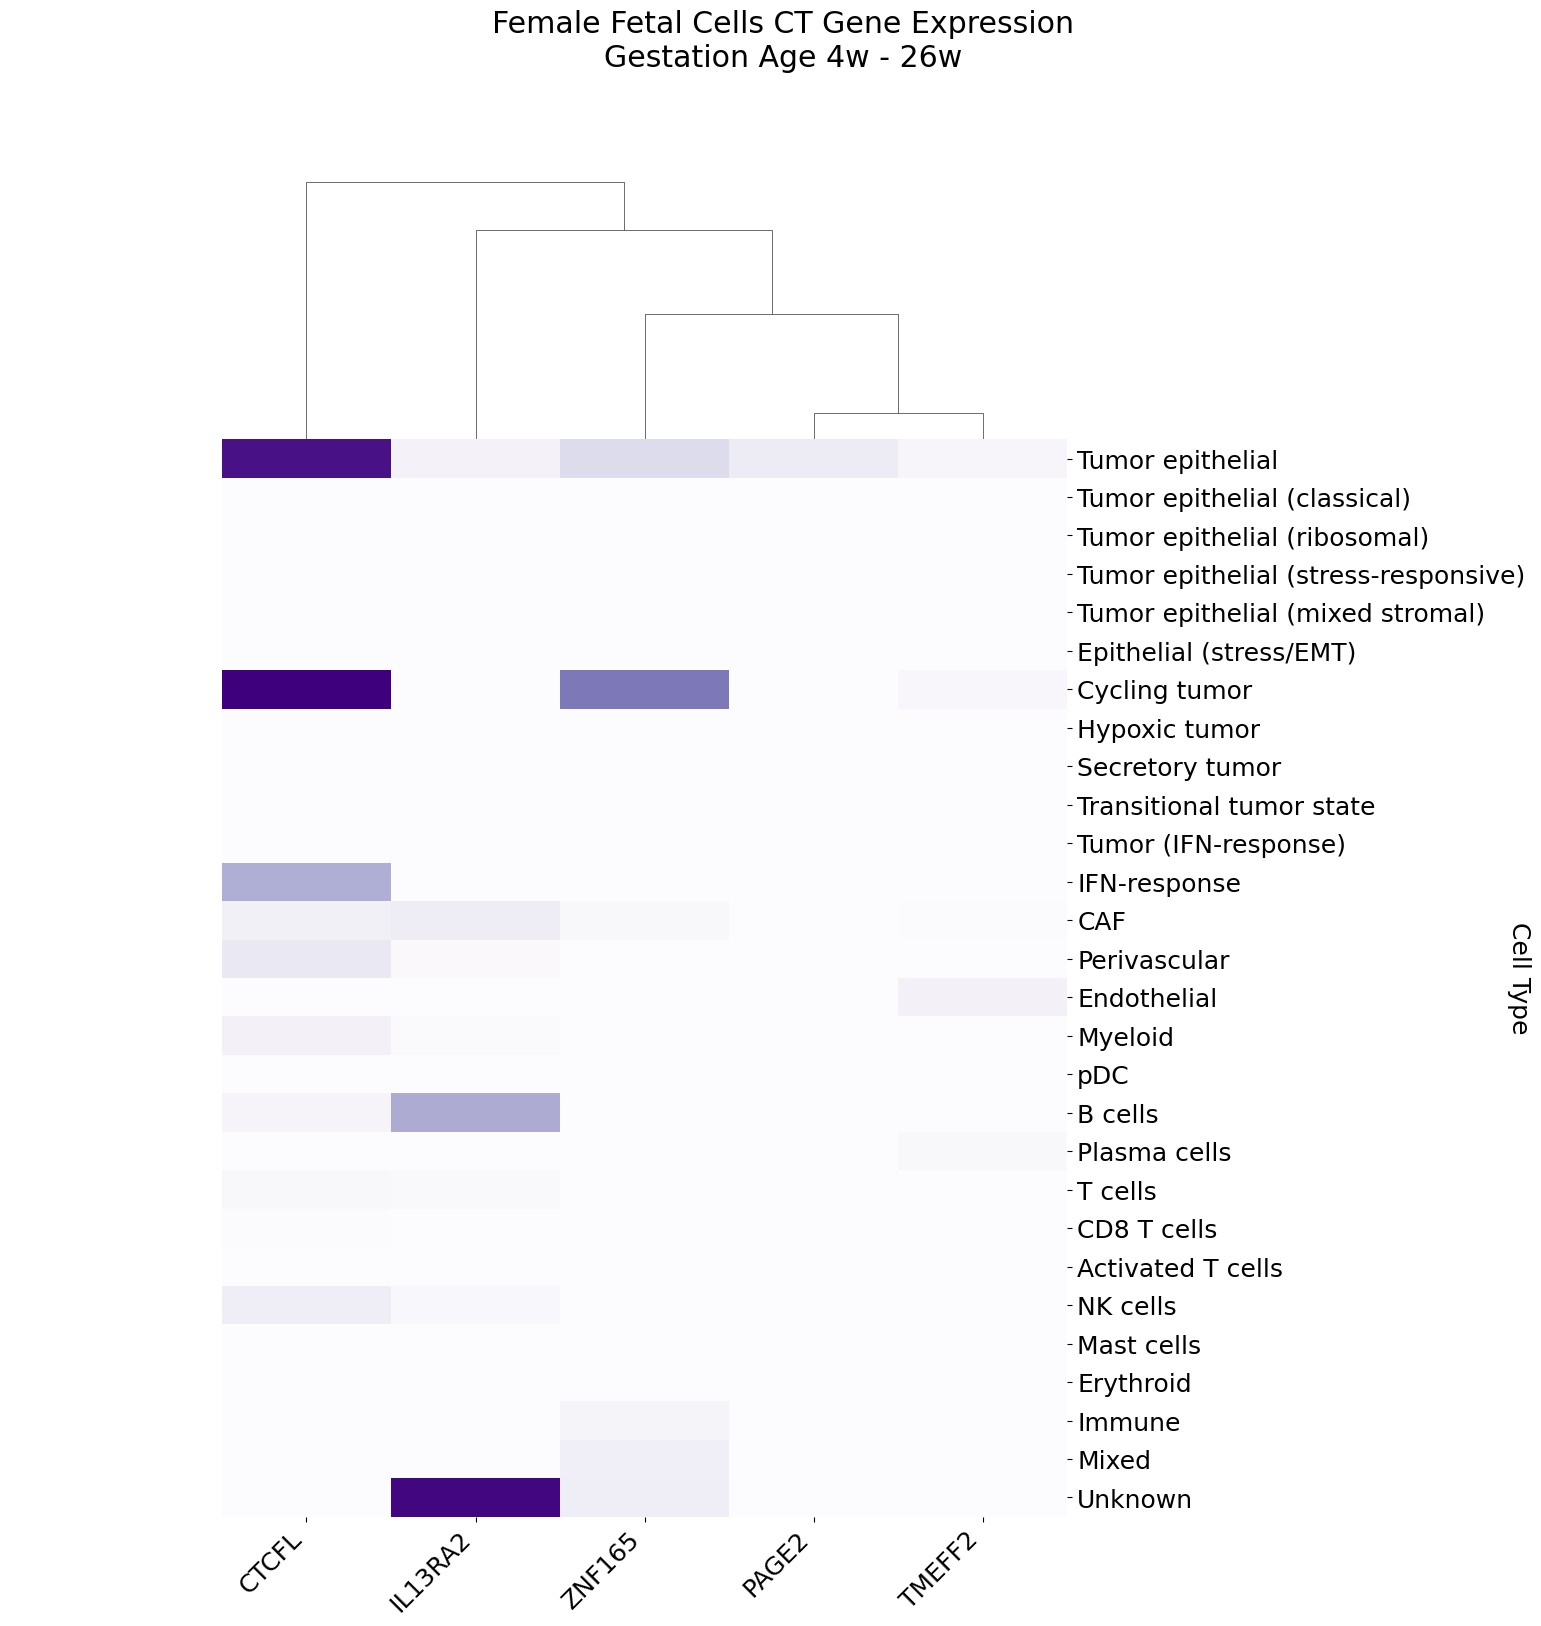

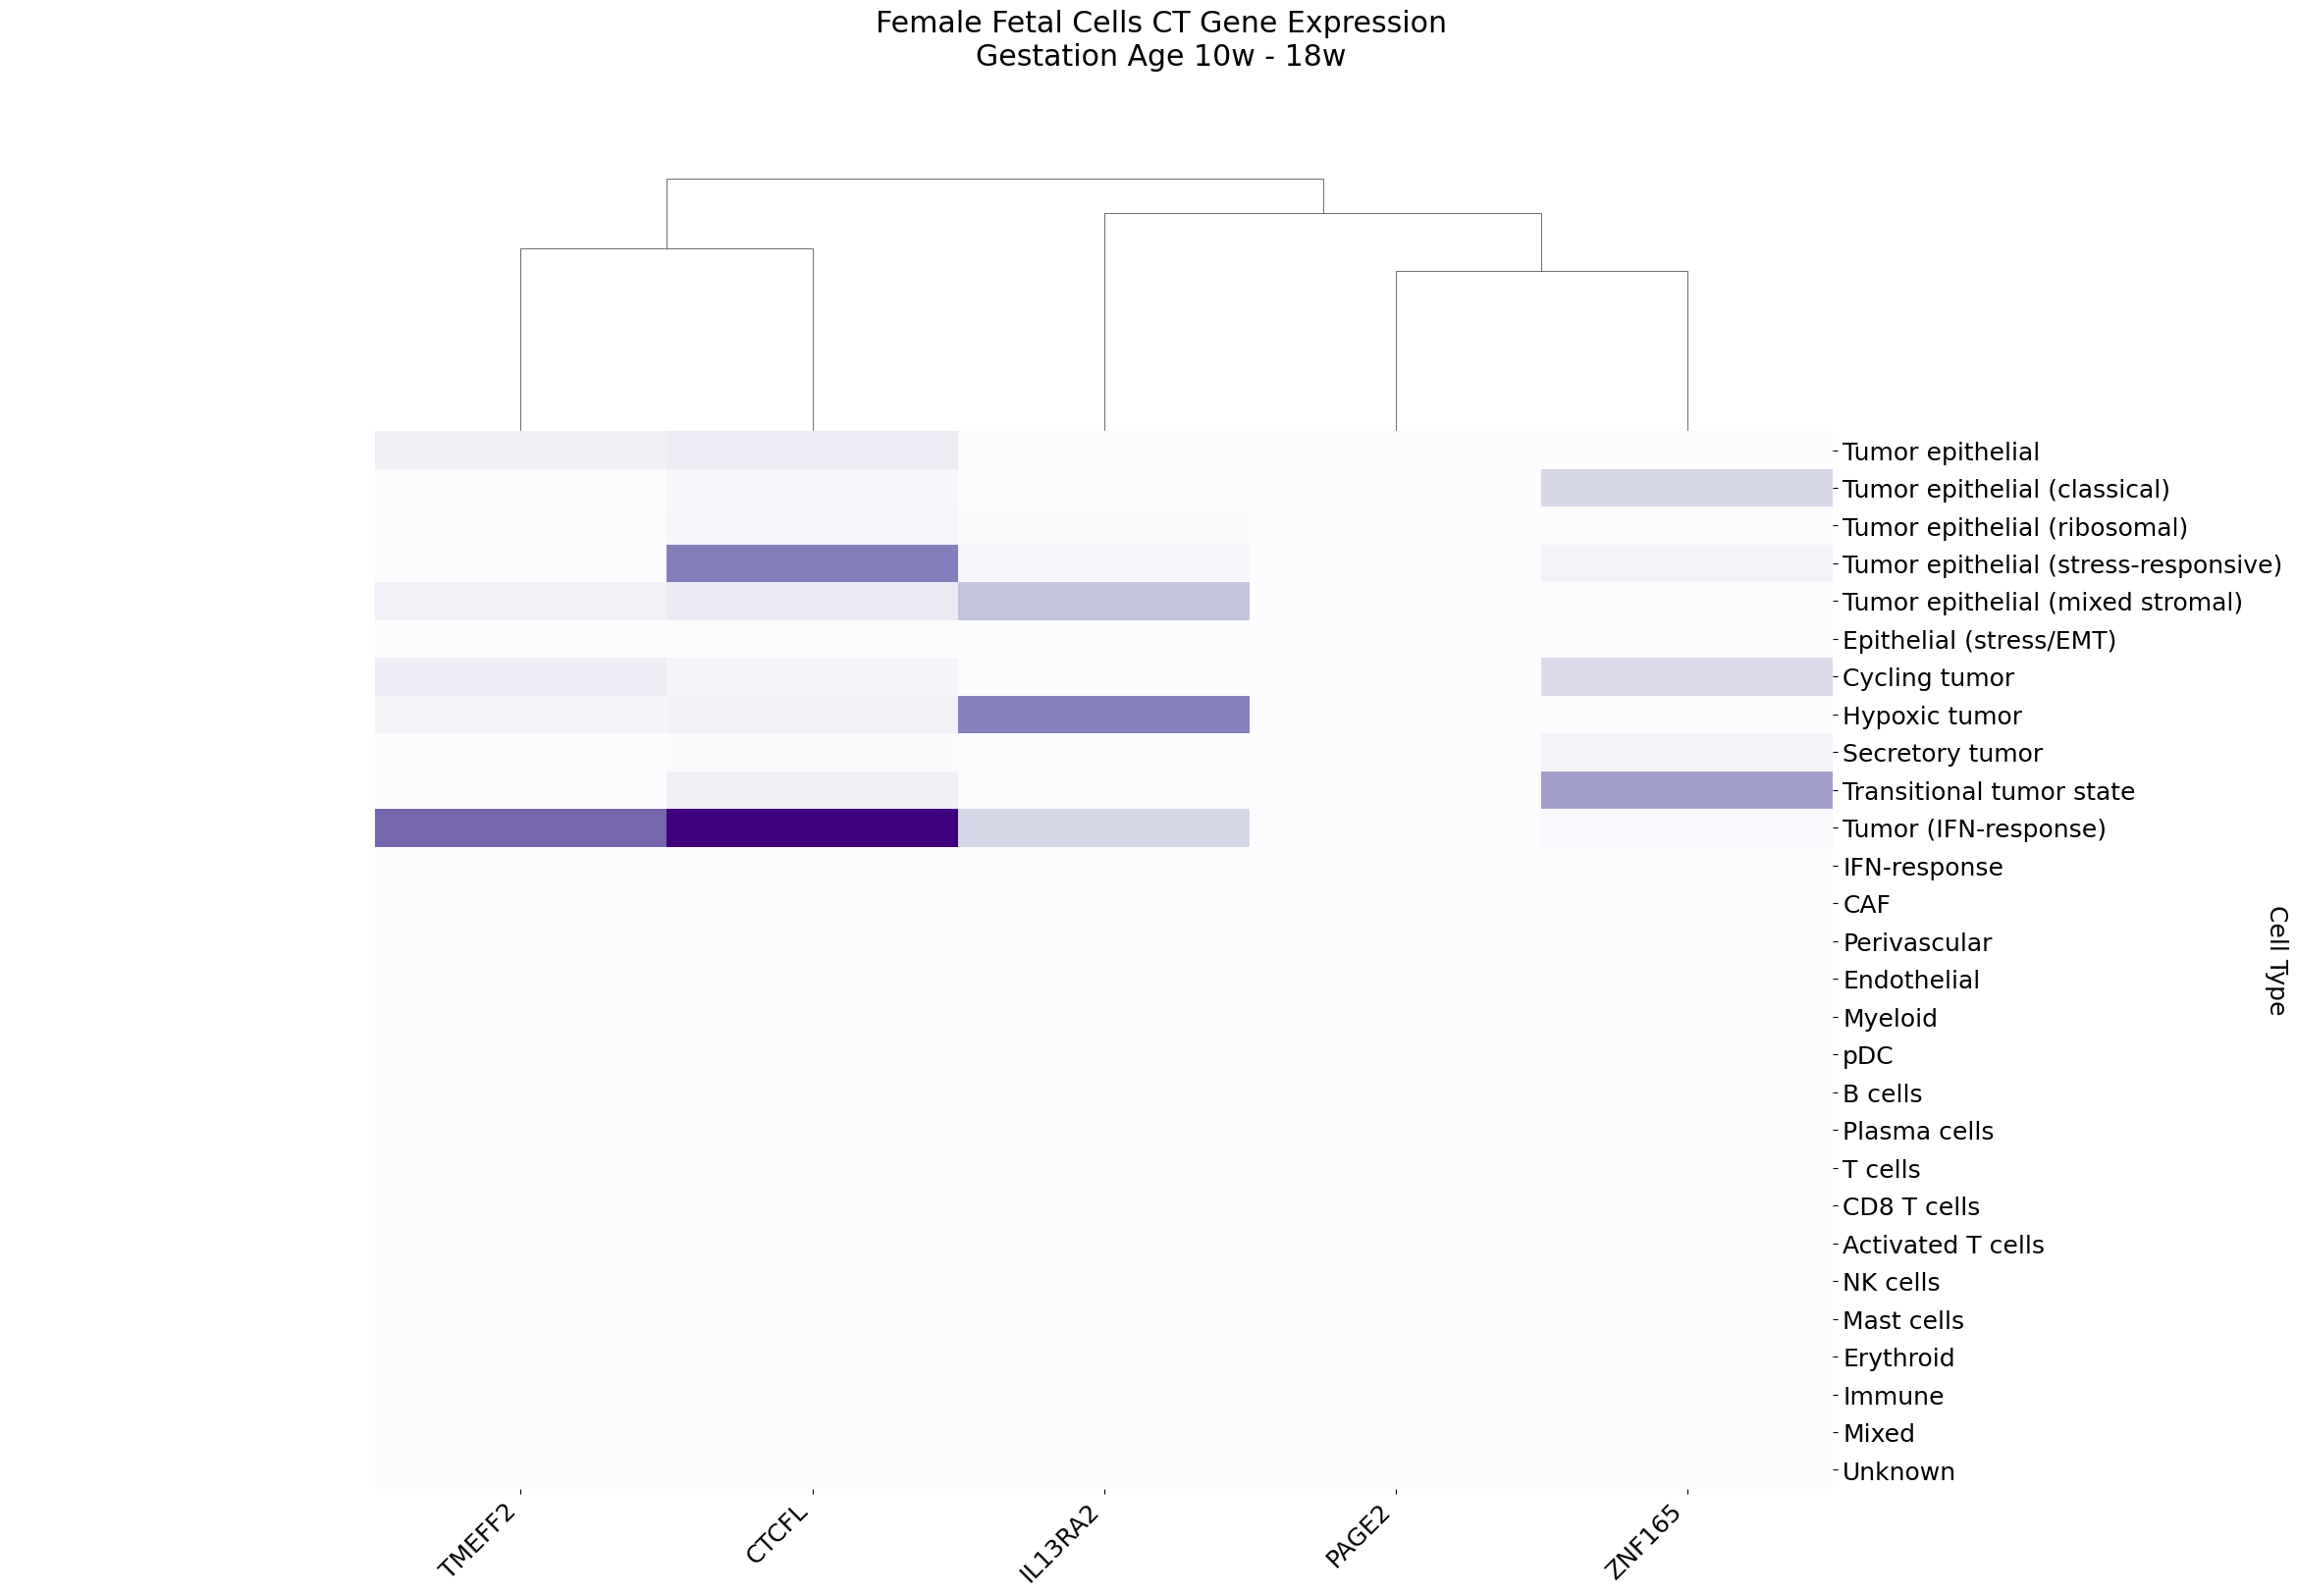

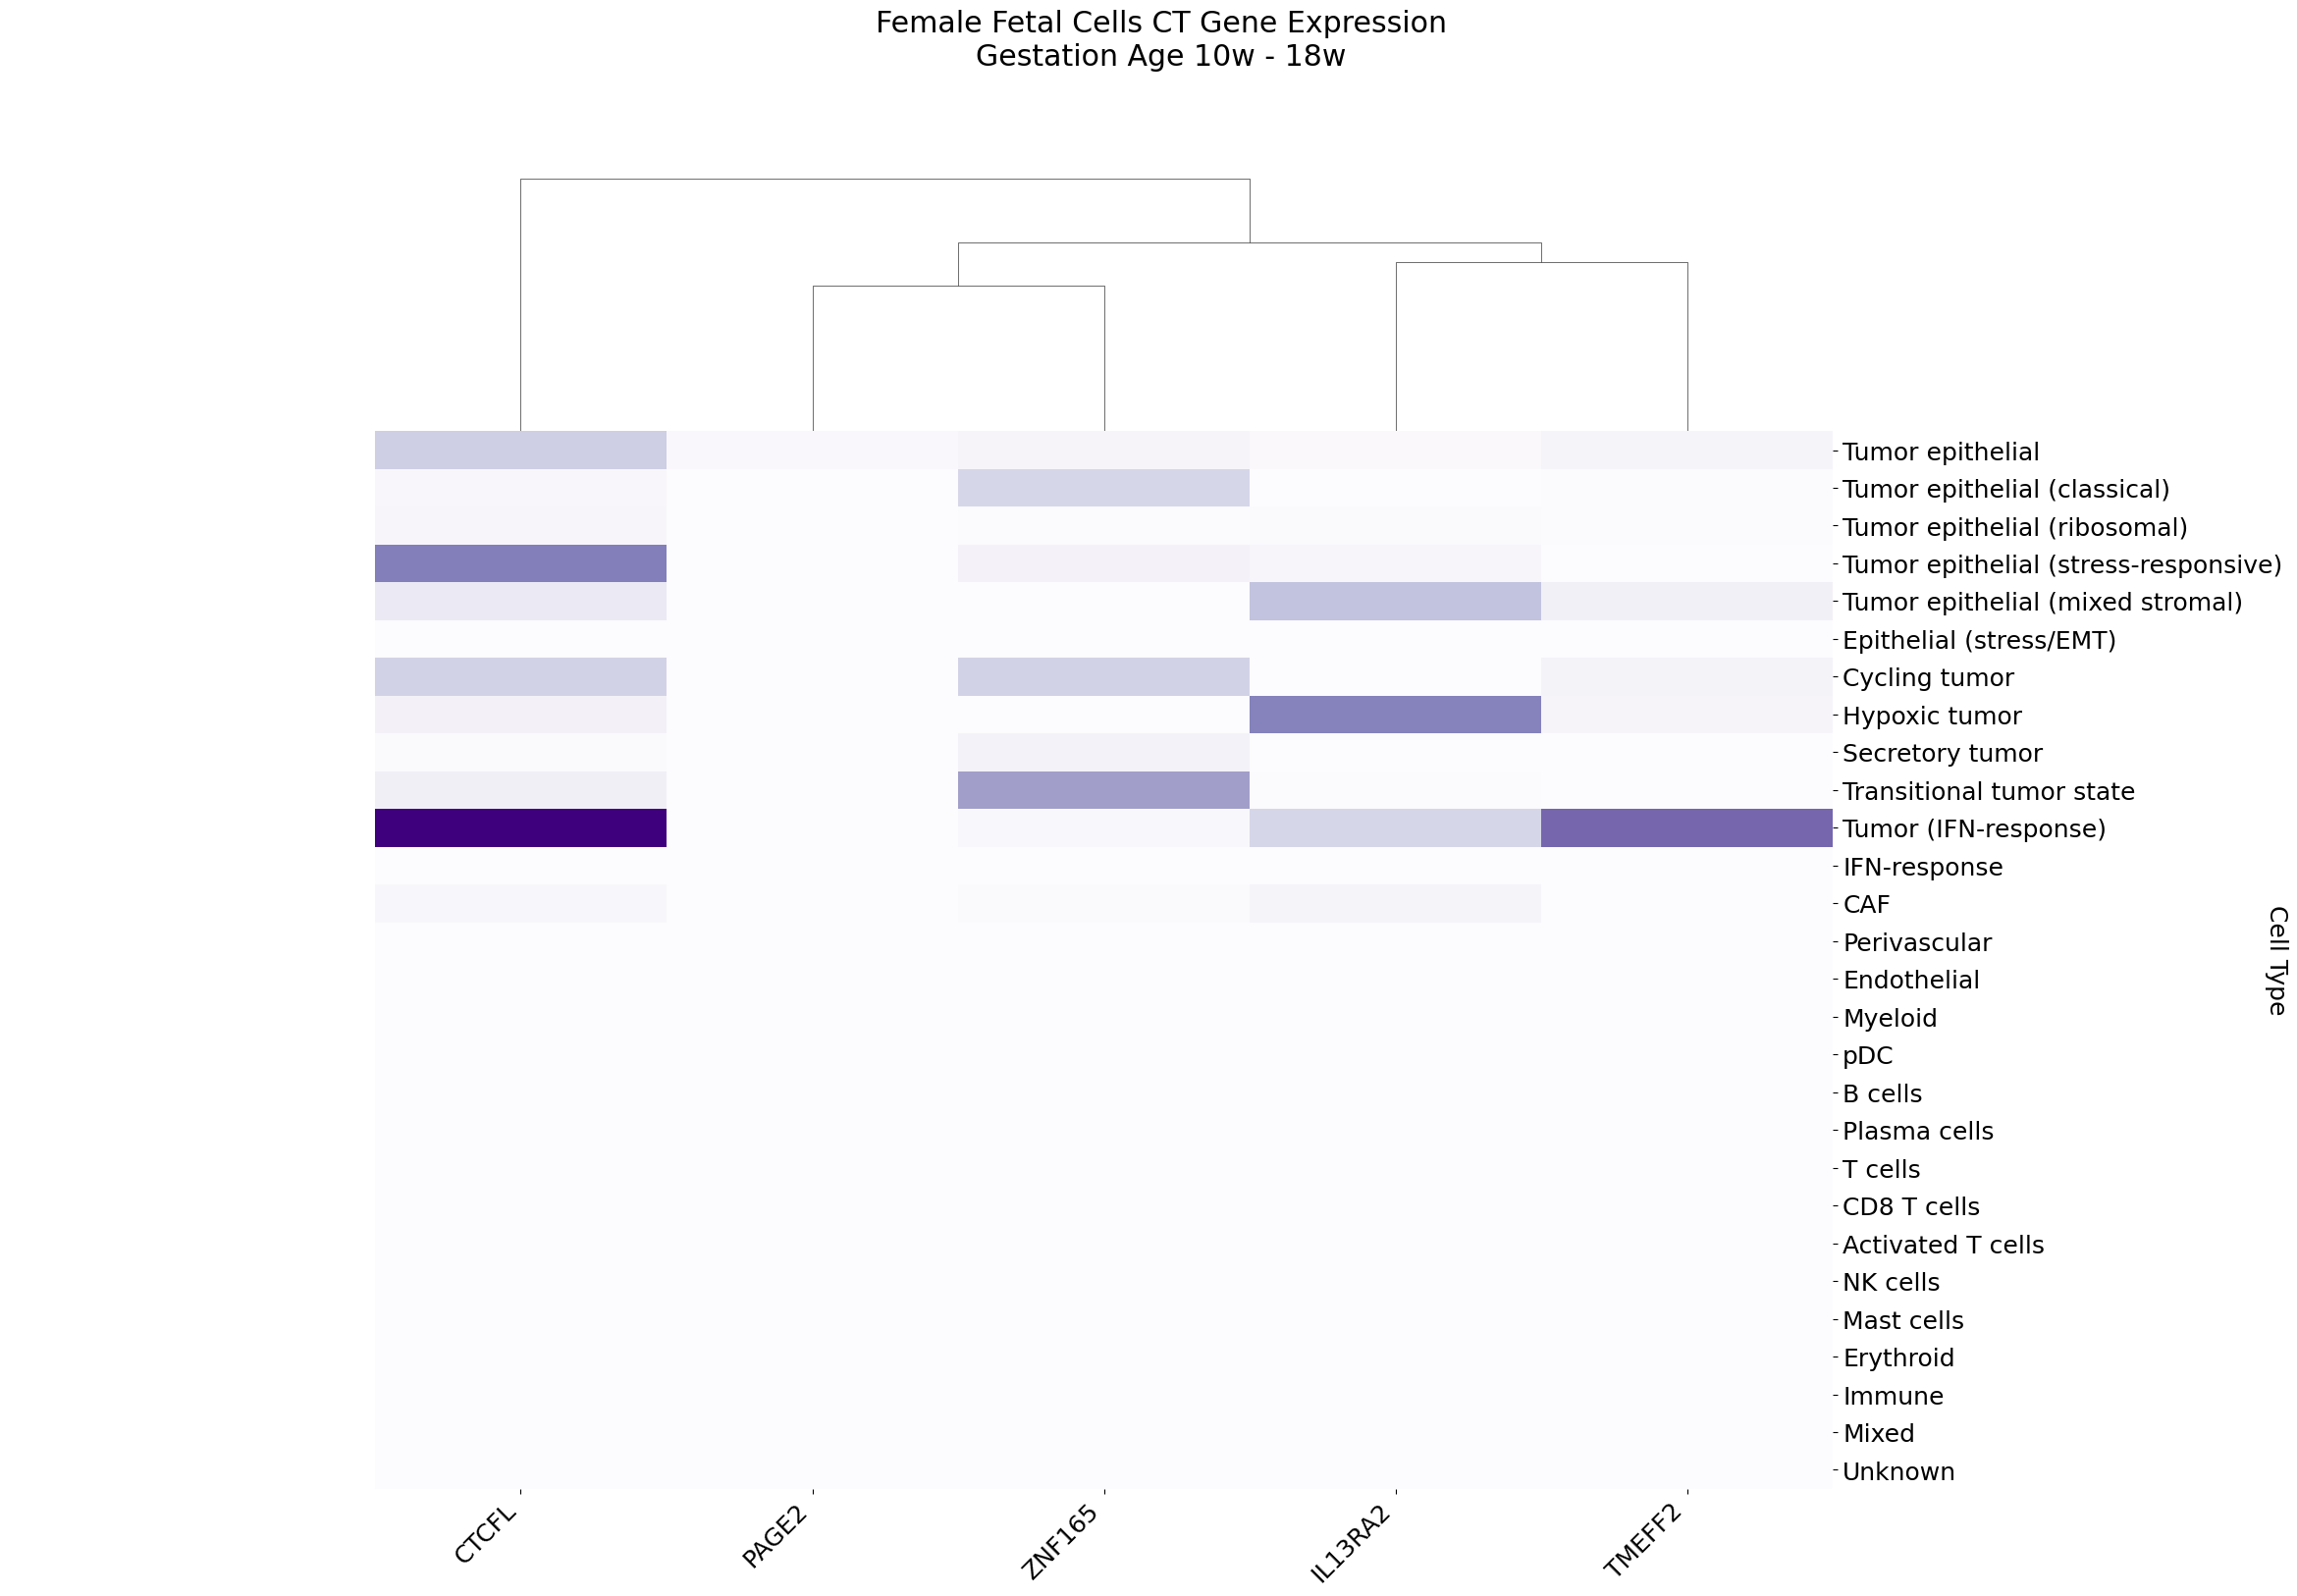

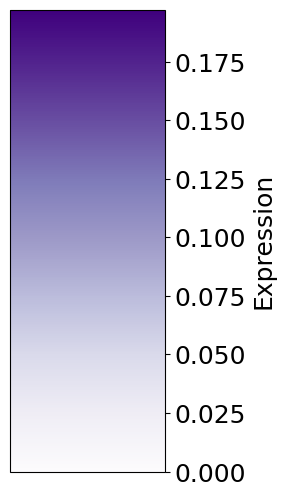

In [29]:
%matplotlib inline

df_mtab_tumors = mtab_tumors_frac_df.reindex(all_cancer_celltypes_order).fillna(0)
all_cancer_gene_order = [g for g in all_cancer_gene_order if g in df_mtab_tumors.columns]
df_mtab_tumors = df_mtab_tumors[all_cancer_gene_order]

df_hgsoc_tumors = df.reindex(all_cancer_celltypes_order).fillna(0)
all_cancer_gene_order = [g for g in all_cancer_gene_order if g in df_hgsoc_tumors.columns]
df_hgsoc_tumors = df_hgsoc_tumors[all_cancer_gene_order]

df_all = df_all.reindex(all_cancer_celltypes_order).fillna(0)
all_cancer_gene_order = [g for g in all_cancer_gene_order if g in df_all.columns]
df_all = df_all[all_cancer_gene_order]
# Set global font size using rcParams
plt.rcParams['font.size'] = 18




plt.rcParams['font.size'] = 18

g = sns.clustermap(df_hgsoc_tumors, row_cluster=False, col_cluster=True, cmap="Purples", cbar_pos=None, figsize=(16, 16))
g.fig.suptitle("Female Fetal Cells CT Gene Expression\nGestation Age 4w - 26w")
g.fig.subplots_adjust(top=0.88)
g.ax_heatmap.set_ylabel("Cell Type", rotation = 270 )
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')

g = sns.clustermap(df_mtab_tumors, row_cluster=False, col_cluster=True, cmap="Purples", cbar_pos=None, figsize=(24, 16))
g.fig.suptitle("Female Fetal Cells CT Gene Expression\nGestation Age 10w - 18w")
g.fig.subplots_adjust(top=0.88)
g.ax_heatmap.set_ylabel("Cell Type")
g.ax_heatmap.set_ylabel("Cell Type", rotation = 270 )
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')

g = sns.clustermap(df_all, row_cluster=False, col_cluster=True, cmap="Purples", cbar_pos=None, figsize=(24, 16))
g.fig.suptitle("Female Fetal Cells CT Gene Expression\nGestation Age 10w - 18w")
g.fig.subplots_adjust(top=0.88)
g.ax_heatmap.set_ylabel("Cell Type")
g.ax_heatmap.set_ylabel("Cell Type", rotation = 270 )
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')


import matplotlib as mpl

vmin = min(df_hgsoc_tumors.min().min(), df_mtab_tumors.min().min())
vmax = max(df_hgsoc_tumors.max().max(), df_mtab_tumors.max().max())

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.cm.Purples

fig, ax = plt.subplots(figsize=(2, 6))
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm)
cb.set_label("Expression")

plt.show()

/tmp/ipykernel_3562561/2722952483.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(groupby)["CTA_score"]
/tmp/ipykernel_3562561/2722952483.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(groupby)["CTA_score"]


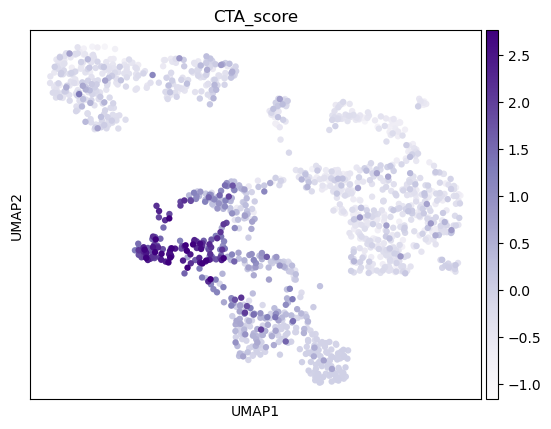

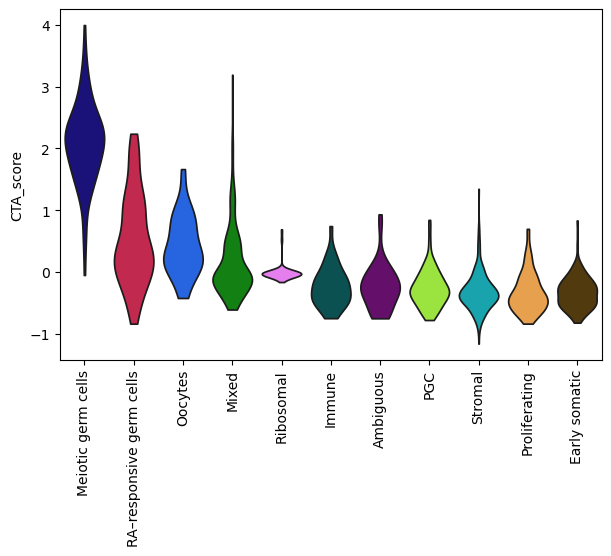

In [ ]:
# Score genes
groupby="celltype_leiden_res_1.0"

sc.tl.score_genes(adata_embryos, gene_list=fetal_genes , score_name="CTA_score", use_raw=True)

order = (
    adata_embryos.obs
    .groupby(groupby)["CTA_score"]
    .mean()
    .sort_values(ascending=False)
    .index
)
adata_embryos.obs[groupby] = adata_embryos.obs[groupby].astype("category")

order = (
    adata_embryos.obs
    .groupby(groupby)["CTA_score"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

adata_embryos.obs[groupby] = adata_embryos.obs[groupby].cat.set_categories(order, ordered=True)
